# Annealing Benchmarking and Verification

Here we apply our developed benchmarking strategy to annealers from DWave.

- sub-system: temperature, susceptibility, and flux noise
- system: spin-glass ground states, fair sampling, and chain breaking
- application: QML

We will focus on the `advantage2_system1` solver:
- Zephyr graph with $m=12, t=4$
- around 5k qubits and 40k couplers
- biases $h\in [-6,6], J\in [-1,1]$

We will also tile jobs across all areas of the QPU, to compress the number of jobs.

> Note: we should set `auto_scale=False` throughout to ensure the `h,J` values we submit are respected.

## Background

Annealers solve Ising problems:

$$E(x)=\sum{h_ix_i}+\sum{J_{ij}x_ix_j}$$

Each anneal starts in an easy quantum state and slowly turns on the problem, over a normalised time $s$ that runs from 0 to 1. Early on the qubits change freely; later they settle, until at the freeze-out point they stop changing altogether, and whatever distribution they had is what we read out.

The freeze-out point for a single qubit is around $s^*\approx 0.68$. Near that point, the distribution of qubit states is a thermal Boltzmann:

$$P(\text{state})\propto e^{-E/k_BT}$$

So the sub-system measurements below are all fits to this frozen distribution.

In [1]:
# imports
import gzip
import json
import time
from itertools import islice
from pathlib import Path
from random import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from dimod import BinaryQuadraticModel, SampleSet
from dwave.system import DWaveSampler
from dwave.system.temperatures import (
    background_susceptibility_bqm,
    freezeout_effective_temperature,
    h_to_fluxbias,
    maximum_pseudolikelihood,
    maximum_pseudolikelihood_temperature,
)
from scipy.constants import Boltzmann, Planck
from scipy.optimize import curve_fit
from scipy.signal import periodogram
from scipy.special import digamma

In [2]:
# setup
SOLVER = "Advantage2_system1"

# device constants
# taken from the docs and the solver-properties spreadsheet:
# https://docs.dwavequantum.com/en/latest/quantum_research/solver_properties_specific.html

# B(s*): problem energy scale at single-qubit freeze-out
B_FREEZEOUT_GHZ = 8.06630607

# single-qubit freezeout point
S_STAR          = 0.684

# M_AFM (pH) for Advantage2_system1; used for h->flux conversion
MAFM_PH         = 0.528

# published physical temperature (mK), and average single-qubit effective temperature
T_DOCS_MK       = 20
W_DOCS          = 0.112

## Saving Data

To be able to rederive results, raw data (problem, config, samples) are saved in `data/<RUN>/<experiment>.json.gz`. We also save the working graph, which changes over time.

Before running an experiment, the notebook checks for that file: if it's already there, it loads it instead of sampling again. So:

- to take new data, use a new `RUN` name (by default, today's date)
- to re-derive the metrics from a past run, set `RUN` to its name and run the notebook as normal

Samples are stored in dimod's format (`SampleSet.to_serializable`) as plain JSON.

In [3]:
# saving and loading data
RUN = time.strftime("%Y-%m-%d")   # or the name of a past run, to re-derive its metrics without the QPU
DATA_DIR = Path("data") / RUN

def save(name, **data):
    path = DATA_DIR / f"{name}.json.gz"
    path.parent.mkdir(parents=True, exist_ok=True)
    with gzip.open(path, "wt") as f:
        json.dump(data, f, default=_to_json)
    print(f"saved {path}")
    return _read(path)

def load(name):
    path = DATA_DIR / f"{name}.json.gz"
    if not path.exists():
        return None
    print(f"loaded {path} (no QPU used)")
    return _read(path)

def _to_json(x):
    "How to store what JSON doesn't know: samplesets in dimod's own format, numpy arrays and numbers as lists."
    if isinstance(x, SampleSet):
        return x.to_serializable()
    if hasattr(x, "tolist"):
        return x.tolist()
    return str(x)   # anything else (e.g. odd metadata) as text, rather than failing after a QPU job

def _read(path):
    with gzip.open(path, "rt") as f:
        return json.load(f, object_hook=lambda d: SampleSet.from_serializable(d) if d.get("type") == "SampleSet" else d)

# JSON has no tuple keys, so we store couplings J = {(u, v): value} as a list of [u, v, value]
def J_to_list(J):
    return [[u, v, w] for (u, v), w in J.items()]

def J_from_list(J_list):
    return {(u, v): w for u, v, w in J_list}

In [4]:
# retrieve the working qubit graph (unless this run already has it)
data = load("graph")
if data is None:
    with DWaveSampler(solver=SOLVER) as sampler:
        G = sampler.to_networkx_graph()
    data = save("graph", solver=SOLVER, nodes=list(G.nodes), edges=list(G.edges))

G = nx.Graph()
G.add_nodes_from(data["nodes"])
G.add_edges_from(data["edges"])
print(f"working graph: {G.number_of_nodes()} qubits, {G.number_of_edges()} couplers")

saved data\2026-09-22\graph.json.gz
working graph: 4575 qubits, 41474 couplers


## Sub-System Benchmarking

The annealer never implements exactly the problem we send it. The $h$ and $J$ we ask for are shifted slightly:

$$h_i\to h_i+\delta h_i,\quad J_{ij}\to J_{ij}+\delta J_{ij}$$

These shifts are the integrated control errors (ICE). They depend on the neighbouring qubits and couplers (and _their_ neighbours), so rather than model them exactly, DWave treats $\delta h,\delta J$ as Gaussian, with a mean and spread that change through the anneal. It calibrates the mean to zero somewhere between the single-qubit freeze-out and the quantum critical point of a 1D Ising chain.

The main sources of ICE are:

- background susceptibility $\chi$: qubits leak into their neighbours
- $1/f$ flux noise: the biases drift slowly over time
- DAC quantisation: $h$ and $J$ can only be set in small discrete steps
- I/O system effects: the ratio $h/J$ can shift slightly with the anneal settings
- qubits not being identical

On top of this, the samples are noisy because of the finite temperature, as well as high-energy photons, readout errors, programming errors, and spin-bath polarisation. All of these are described in the [docs](https://docs.dwavequantum.com/en/latest/quantum_research/errors.html).

Here we measure the temperature, $\chi$, and the $1/f$ noise.

### Temperature

The higher the temperature, the noisier the qubits, i.e. the less likely they are to take the lowest-energy state.

There are two temperatures:

- effective temperature `w` is measured in bias units (same as $h$), and is returned by the DWave functions
- physical temperature $T$ is in Kelvin and is converted using $T=B(s^*)2\pi\hbar w/2k_B$ with $B(s^*)\approx 8.066\text{ GHz}$

Always compare a $w$ with a $w$, and only convert to Kelvin at the end. The docs quote $T=20\pm1$ mK and an average $w\approx0.112$. The conversion is only approximate, so these don't quite agree ($w=0.112$ is about 22 mK, and 20 mK is $w\approx0.103$): expect something around $w\approx0.10-0.12$.

Then, note that different subsets of qubits will freeze at different points in the anneal, and thus will report different temperatures:

- single qubits
- coupled spin glass
- multi-qubit cluster

We start with single qubits, and come back to the other two below.

For a single qubit with bias $h$, the two states have energies $\pm h$, so the Boltzmann distribution gives $P(+1)/P(-1)=e^{-2h/w}$. The average spin is then

$$\braket{\sigma_z}=\tanh{\frac{h_0-h}{w}}$$

where $h_0$ absorbs any small built-in bias. Therefore, we will sweep $h$ (set all $J$ to 0), and measure the average spin at each. Then, we will fit the above function: the fitted width $w$ is the effective temperature.

To get a good average, we tile: every qubit on the chip is given one of the bias values, so each bias is measured on ~200 qubits at once, and the whole sweep is a single job. With $J=0$ the qubits can't affect each other, so each one is its own independent experiment. Note this gives the average temperature across the chip, which can differ a little from any one qubit.

For the error bars, the independent unit is the qubit, not the individual read: reads on the same qubit are correlated, and every qubit has a slightly different $h_0$ and $w$. So at each bias we take one average spin per qubit, and use their spread across qubits ($\text{std}/\sqrt{N}$) as the error bar.

Once we have done the manual implementation, we will cross-check using DWave's own diagnostic functions.

In [5]:
# setup
NUM_ANNEALS = 1000

# we concentrate the sweep near 0
_bias_seeds = np.logspace(-1.2, 0.4, 10) / 10
bias_values = np.array((-_bias_seeds).tolist()[::-1] + [0.0] + _bias_seeds.tolist())

# run, all qubits in one job (unless this run already has it)
data = load("temperature")
if data is None:
    # tile: give every qubit one of the bias values, cycling through them
    qubits = list(G.nodes)
    h = {q: bias_values[i % len(bias_values)] for i, q in enumerate(qubits)}
    with DWaveSampler(solver=SOLVER) as sampler:
        ss_T = sampler.sample_ising(h, {}, num_reads=NUM_ANNEALS, label="tiled temperature sweep", auto_scale=False)
    print(f"1 job: {len(qubits)} qubits tiled over {len(bias_values)} bias values")
    data = save("temperature", bias_values=bias_values, qubits=qubits, samples=ss_T)

# qubit i was given bias_values[i % len(bias_values)]
bias_values, qubits, ss_T = np.array(data["bias_values"]), data["qubits"], data["samples"]

1 job: 4575 qubits tiled over 21 bias values
saved data\2026-09-22\temperature.json.gz


Effective temperature: 0.1244 +-0.0003 (h0=-0.0003 +-0.0001)
Physical temperature: 24.07 +-0.06 mK
Docs: w = 0.112, or w = 0.103 from T = 20 mK


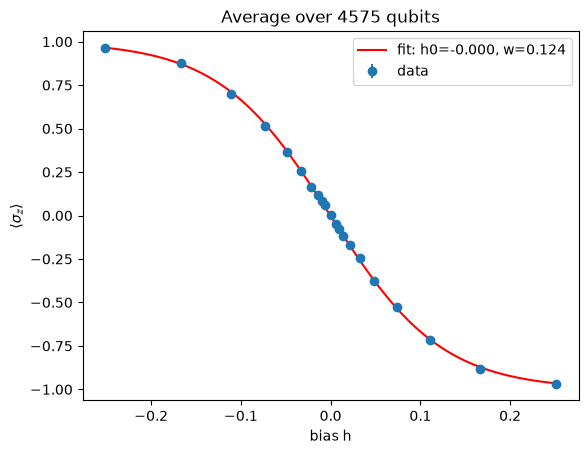

In [6]:
# analyse
def tanh_response(h, h0, w):
    return np.tanh((h0 - h) / w)

def w_to_kelvin(w):
    "Convert an effective temperature w (bias units) to physical temperature T (kelvin)."
    return B_FREEZEOUT_GHZ * 1e9 * Planck * w / (2 * Boltzmann)

def mean_spin(samples, qubits):
    "Average spin of a group of qubits (one qubit, or a whole cluster), over all reads."
    spins = samples.record.sample[:, [samples.variables.index(q) for q in qubits]].mean(axis=1)
    return np.average(spins, weights=samples.record.num_occurrences)

def fit_temperature(biases, spins):
    "Fit the tanh to the average spin at each bias. spins[j] holds one average spin per qubit (or cluster) at biases[j]."
    means = np.array([np.mean(s) for s in spins])
    errs = np.array([np.std(s, ddof=1) / np.sqrt(len(s)) for s in spins])   # spread across qubits
    keep = errs > 0   # skip fully saturated biases: every read gave the same spin, so there's no spread to use
    popt, pcov = curve_fit(tanh_response, biases[keep], means[keep], p0=[0.0, 0.1], sigma=errs[keep], absolute_sigma=True)
    return popt, np.sqrt(np.diag(pcov)), means, errs

# one average spin per qubit, grouped by the bias each qubit was given
spins = [[mean_spin(ss_T, [q]) for q in qubits[j::len(bias_values)]] for j in range(len(bias_values))]
popt, perr, avg_spins, spin_errs = fit_temperature(bias_values, spins)
w_tanh, w_tanh_err = popt[1], perr[1]

print(f"Effective temperature: {w_tanh:.4f} +-{w_tanh_err:.4f} (h0={popt[0]:.4f} +-{perr[0]:.4f})")
print(f"Physical temperature: {w_to_kelvin(w_tanh)*1000:.2f} +-{w_to_kelvin(w_tanh_err)*1000:.2f} mK")
print(f"Docs: w = {W_DOCS}, or w = {freezeout_effective_temperature(B_FREEZEOUT_GHZ, T_DOCS_MK):.3f} from T = {T_DOCS_MK} mK")

hh = np.linspace(min(bias_values), max(bias_values), 200)
plt.errorbar(bias_values, avg_spins, yerr=spin_errs, fmt='o', label='data')
plt.plot(hh, tanh_response(hh, *popt), 'r-', label=f'fit: h0={popt[0]:.3f}, w={w_tanh:.3f}')
plt.xlabel('bias h')
plt.ylabel(r'$\langle\sigma_z\rangle$')
plt.legend()
plt.title(f"Average over {len(qubits)} qubits")
plt.show()

- `fast_effective_temperature` submits random single-qubit problems across the whole chip, and fits a temperature to the samples by maximum pseudo-likelihood, so it should agree with our results
- `maximum_pseudolikelihood_temperature` fits a temperature to samples from a spin glass (random $J$), which is a coupled problem with a different freeze-out point, and so should have a higher effective temperature

`fast_effective_temperature` doesn't hand back its samples, so we couldn't save them. Instead, we do its two steps ourselves: sample random biases in its default range ($\pm1/6.1$), then fit with `maximum_pseudolikelihood_temperature`, exactly as it does inside.

> Note: if you do call `fast_effective_temperature` directly, pass `num_reads` inside `sampler_params`, not on its own. Otherwise it raises `ValueError: sampler_params['num_reads'] != num_reads`.

In [7]:
# run (unless this run already has it)
data = load("sdk_checks")
if data is None:
    with DWaveSampler(solver=SOLVER) as sampler:
        # what fast_effective_temperature does: a random bias on every qubit, in its default range
        h_fast = {q: (2 * random() - 1) / 6.1 for q in G.nodes}
        ss_fast = sampler.sample_ising(h_fast, {}, num_reads=NUM_ANNEALS, label="random single-qubit biases", auto_scale=False)

        # a spin glass: random couplers, no biases
        J_sg = {e: 1 - 2 * random() for e in G.edges}
        ss_sg = sampler.sample_ising({}, J_sg, num_reads=1000, label="spin glass temperature", auto_scale=False)
    data = save("sdk_checks", h_fast=list(h_fast.items()), fast=ss_fast, J_sg=J_to_list(J_sg), spin_glass=ss_sg)

# analyse: both are maximum pseudo-likelihood fits to the samples
bqm_fast = BinaryQuadraticModel.from_ising(dict(data["h_fast"]), {})
bqm_sg = BinaryQuadraticModel.from_ising({}, J_from_list(data["J_sg"]))
w_fast, _ = maximum_pseudolikelihood_temperature(bqm_fast, data["fast"], optimize_method="bisect")   # as fast_effective_temperature does
w_mpl, _ = maximum_pseudolikelihood_temperature(bqm_sg, data["spin_glass"])

print(f"* fast: w = {w_fast:.4f}")
print(f"* MPL : w = {w_mpl:.4f}  (different freeze-out point)")

saved data\2026-09-22\sdk_checks.json.gz
* fast: w = 0.1249
* MPL : w = 0.1433  (different freeze-out point)


### Clusters

A single qubit only tells us about the device at the single-qubit freeze-out. To look at other points in the anneal, we can bind a few qubits together so strongly that they act as one _logical_ spin: a cluster. A bigger, stiffer spin freezes _earlier_ in the anneal than a lone qubit, so it reports on the device at an earlier point.

Zephyr is very well connected (each qubit has up to 20 neighbours), so growing a cluster outwards from a seed qubit gives a tight, nearly fully-connected group. We:

- grow each cluster breadth-first until it has `CLUSTER_SIZE` qubits, skipping any that are too loosely connected (a chain or tree of qubits is floppy, so we insist on at least one loop)
- set $J=-1$ (the strongest ferromagnet) on every coupler inside the cluster, so its qubits all align
- give every qubit in a cluster the same bias

Clusters don't share any qubits, and the couplers between them are left at $J=0$, so we can tile hundreds of them in one job.

In [8]:
# grow disjoint clusters breadth-first
CLUSTER_SIZE = 4

def disjoint_clusters(G, size, n):
    "Grow n non-overlapping clusters of `size` qubits, skipping loosely connected ones."
    free = set(G.nodes)
    clusters = []
    for seed in G.nodes:
        if seed not in free:
            continue
        cluster = [seed] + [v for _, v in islice(nx.bfs_edges(G.subgraph(free), seed), size - 1)]
        if len(cluster) == size and G.subgraph(cluster).number_of_edges() >= size:   # at least one loop
            free -= set(cluster)
            clusters.append(cluster)
            if len(clusters) == n:
                return clusters
    raise RuntimeError(f"only found {len(clusters)} clusters, needed {n}")

We repeat the temperature sweep on clusters: each bias value is given to `CLUSTERS_PER_BIAS` clusters, all tiled in one job, and we fit the same `tanh` to their average spin. As before, the error bars come from the spread, this time across clusters.

Careful with the units here! Every qubit in a cluster gets bias $h$, so the cluster as a whole feels $\text{size}\times h$. The fitted width therefore comes out $\text{size}$ times too small, $w_\text{cluster}=w_\text{logical}/\text{size}$, which does _not_ mean the cluster is colder. The number to compare with the single-qubit $w$ is the logical temperature $w_\text{logical}=\text{size}\times w_\text{cluster}$.

We expect $w_\text{logical}$ to be higher than the single-qubit $w$: the cluster freezes earlier, where $B(s)$ is smaller, so $w=2k_BT/B(s)$ is bigger.

In [9]:
# setup
NUM_ANNEALS = 1000
cluster_bias = np.linspace(-0.2, 0.2, 13)   # per-qubit bias
CLUSTERS_PER_BIAS = 40

# run (unless this run already has it)
data = load("cluster_temperature")
if data is None:
    # tile: CLUSTERS_PER_BIAS clusters at every bias value, all in one job
    clusters = disjoint_clusters(G, CLUSTER_SIZE, len(cluster_bias) * CLUSTERS_PER_BIAS)
    h, J = {}, {}
    for i, cluster in enumerate(clusters):
        for q in cluster:
            h[q] = cluster_bias[i % len(cluster_bias)]
        for u, v in G.subgraph(cluster).edges:
            J[(u, v)] = -1.0   # bind the cluster into one logical spin

    with DWaveSampler(solver=SOLVER) as sampler:
        ss_C = sampler.sample_ising(h, J, num_reads=NUM_ANNEALS, label="tiled cluster temperature", auto_scale=False)
    print(f"1 job: {len(clusters)} clusters of {CLUSTER_SIZE} qubits, {CLUSTERS_PER_BIAS} per bias value")
    data = save("cluster_temperature", cluster_bias=cluster_bias, clusters=clusters, J=J_to_list(J), samples=ss_C)

# cluster i was given cluster_bias[i % len(cluster_bias)]; and the settings this run was taken with
cluster_bias, clusters, ss_C = np.array(data["cluster_bias"]), data["clusters"], data["samples"]
CLUSTER_SIZE, CLUSTERS_PER_BIAS = len(clusters[0]), len(clusters) // len(cluster_bias)

1 job: 520 clusters of 4 qubits, 40 per bias value
saved data\2026-09-22\cluster_temperature.json.gz


w_cluster = 0.0836 +-0.0006  (per-qubit bias units, so 4x too small)
w_logical = 0.3342 +-0.0025  (compare with the single-qubit w = 0.1244)


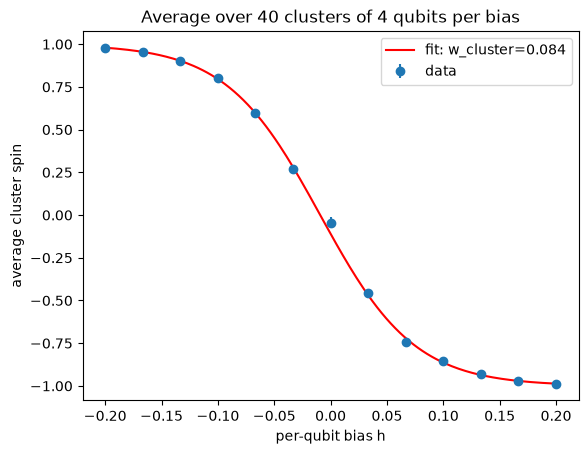

In [10]:
# analyse: one average spin per cluster, grouped by the bias each cluster was given
spins = [[mean_spin(ss_C, c) for c in clusters[j::len(cluster_bias)]] for j in range(len(cluster_bias))]
popt_c, perr_c, avg_c, err_c = fit_temperature(cluster_bias, spins)
w_cluster, w_cluster_err = popt_c[1], perr_c[1]
w_logical = CLUSTER_SIZE * w_cluster

print(f"w_cluster = {w_cluster:.4f} +-{w_cluster_err:.4f}  (per-qubit bias units, so {CLUSTER_SIZE}x too small)")
print(f"w_logical = {w_logical:.4f} +-{CLUSTER_SIZE * w_cluster_err:.4f}  (compare with the single-qubit w = {w_tanh:.4f})")

hh = np.linspace(min(cluster_bias), max(cluster_bias), 200)
plt.errorbar(cluster_bias, avg_c, yerr=err_c, fmt='o', label='data')
plt.plot(hh, tanh_response(hh, *popt_c), 'r-', label=f'fit: w_cluster={w_cluster:.3f}')
plt.xlabel('per-qubit bias h')
plt.ylabel('average cluster spin')
plt.legend()
plt.title(f"Average over {CLUSTERS_PER_BIAS} clusters of {CLUSTER_SIZE} qubits per bias")
plt.show()

### Susceptibility

$\chi$ is the "leakiness" of the qubits, acting through the couplers:

- a bias on one qubit leaks to the neighbours
- a qubit mediates a weak coupling between two of its neighbours

For example, take a line of three spins, with couplers 1-2 and 2-3:

$$E=h_1s_1+h_2s_2+h_3s_3+J_{12}s_1s_2+J_{23}s_2s_3$$

The susceptibility adds

$$\delta E_\chi=\chi\left(h_1J_{12}s_2+h_2J_{12}s_1+h_2J_{23}s_3+h_3J_{23}s_2\right)+\chi J_{12}J_{23}s_1s_3$$

The terms in brackets are the biases leaking along each coupler, and the last term is a new coupling between spins 1 and 3, passed through spin 2.

In general, it modifies the implemented Hamiltonian thusly:

$$\text{BQM}=\text{BQM}(\chi=0)+\chi\, d\text{BQM}$$

and `background_susceptibility_bqm` builds $d\text{BQM}$ for us. Here we use a normalised $\chi=M_{\text{AFM}}\chi_q$, where $\chi_q=dI_p/d\Phi_q$ is the _physical_ qubit susceptibility. $\chi$ is small and negative: the docs quote around $-0.04$ early in the anneal, down to $-0.015$ late in the anneal.

Note that $\chi$ only has an effect when $J\neq 0$!

There are two traps when measuring it:

- $\chi$ doesn't show up in the returned energies, since those are calculated from the Hamiltonian we _sent_. It only shows up in _which_ states come back, so we fit to the states.
- on a spin glass, $\chi$ and the temperature have almost the same effect on the states, so they are hard to tell apart.

So we sample a random spin glass (zero biases, random couplers) and fit the temperature and $\chi$ _together_, with `maximum_pseudolikelihood`. We start the fit from the $J=0$ temperature measured above (where $\chi$ can't act), and check that the fitted temperature comes out close to it. The spin glass freezes at a slightly different point, so they won't match exactly, but if they are far apart (e.g. 2x) the fit has traded temperature for $\chi$, and we shouldn't trust it.

In [11]:
NUM_ANNEALS = 2000

# run (unless this run already has it)
data = load("susceptibility")
if data is None:
    # create the spin glass
    bqm = BinaryQuadraticModel.from_ising({}, {e: 1 - 2 * random() for e in G.edges})

    # sample from it
    with DWaveSampler(solver=SOLVER) as sampler:
        samples = sampler.sample(bqm, num_reads=NUM_ANNEALS, auto_scale=False)
    data = save("susceptibility", J=J_to_list(bqm.quadratic), samples=samples)

bqm, samples = BinaryQuadraticModel.from_ising({}, J_from_list(data["J"])), data["samples"]

# calculate the correction dBQM
dbqm = background_susceptibility_bqm(bqm)

# fit chi
x, _ = maximum_pseudolikelihood(
    bqms = [bqm, dbqm],
    sampleset = samples,
    x0 = [-1/w_fast, 0]
)

w_joint, chi = -1 / x[0], x[1] / x[0]

print(f"Measured chi: {chi:.4f}")
print(f"Seeded chi-free w_fast: {w_fast:.4f}")
print(f"Measured chi-corrected w_joint: {w_joint:.4f}")
print(f"w_joint / w_fast = {w_joint/w_fast:.4f} (close to 1 = trustworthy)")

saved data\2026-09-22\susceptibility.json.gz
Measured chi: -0.0181
Seeded chi-free w_fast: 0.1249
Measured chi-corrected w_joint: 0.1500
w_joint / w_fast = 1.2014 (close to 1 = trustworthy)


> Why not measure $\chi$ more directly, from two coupled qubits? We tried: sweep $(h_0,h_1)$ on a strongly-coupled pair and look for where the ground state flips. But $\chi$ only moves that boundary by about $|\chi J|\approx0.02$, about 8x smaller than the grid spacing we used, so the shift can't be seen. Fitting the thermal probabilities instead needs the temperature, and a coupled pair freezes at a different point to a lone qubit, so plugging in the single-qubit $w$ gives $\chi$ with the wrong sign. Pairs of clusters are even worse. The joint fit above avoids both problems.

### $1/f$ Flux Noise

Each superconducting circuit suffers from $1/f$ flux noise, causing the qubit biases to drift slowly over time (the couplers have it too, but the effect is negligible). The power spectral density (how much noise there is at each frequency) looks like

$$S(f)=\frac{A^2}{f^\alpha}+c$$

$A$ is the amplitude of the noise at $1\text{ Hz}$: the docs quote $A\approx2\,\mu\Phi_0/\sqrt{\text{Hz}}$ (in flux units) and $0.75\le\alpha<1$. $c$ is a flat noise floor from the measurement itself (see below). DWave corrects the drift hourly, so we need to turn that correction off.

To measure this, we set $h=J=0$, disable `flux_drift_compensation`, and record the mean spin as a time series. We measure a lone qubit and a cluster in the same job: the cluster freezes earlier, so it shows the noise at an earlier point in the anneal. Then, we can analyse the time series and fit to extract $A$ and $\alpha$.

Note that the longer we run the experiment, the lower the frequencies we can see: the observable band runs from $1/\text{duration}$ to $1/(2\times\text{cadence})$.

In [12]:
# sample every CADENCE s for DURATION s

CADENCE, DURATION = 2, 500
TARGET_QUBIT = 1
NUM_ANNEALS = 2000

# run (unless this run already has it)
data = load("flux_noise")
if data is None:
    print(f"Sampling every {CADENCE} s for {DURATION} s...")
    print(f"Observable frequency band: {1/DURATION:.3f} Hz to {1/(2*CADENCE):.3f} Hz")
    print(f"Expected number of jobs: {DURATION/CADENCE:.0f}")

    # a lone qubit, plus a cluster that avoids it
    cluster = disjoint_clusters(G.subgraph(set(G) - {TARGET_QUBIT}), CLUSTER_SIZE, 1)[0]
    bqm = BinaryQuadraticModel.from_ising(
        {q: 0 for q in [TARGET_QUBIT] + cluster},
        {(u, v): -1.0 for u, v in G.subgraph(cluster).edges},
    )

    times = []
    results = []

    with DWaveSampler(solver=SOLVER) as sampler:
        t0 = time.time()
        while time.time() - t0 < DURATION:
            t_ps = time.time()
            samples = sampler.sample(
                bqm,
                num_reads=NUM_ANNEALS,
                auto_scale=False,
                flux_drift_compensation=False,
                reduce_intersample_correlation=True
            )

            now = time.time()
            times.append(now - t0)
            results.append(samples)
            print(f"Sampled at t = {now - t0:.1f} s")

            time.sleep(max(0, CADENCE-(now-t_ps)))
    data = save("flux_noise", target_qubit=TARGET_QUBIT, cluster=cluster, J=J_to_list(bqm.quadratic), times=times, samples=results)

TARGET_QUBIT, cluster, times, results = data["target_qubit"], data["cluster"], data["times"], data["samples"]

Sampling every 2 s for 500 s...
Observable frequency band: 0.002 Hz to 0.250 Hz
Expected number of jobs: 250
Sampled at t = 0.1 s
Sampled at t = 2.0 s
Sampled at t = 4.0 s
Sampled at t = 6.0 s
Sampled at t = 8.0 s
Sampled at t = 10.0 s
Sampled at t = 12.0 s
Sampled at t = 14.0 s
Sampled at t = 16.0 s
Sampled at t = 18.0 s
Sampled at t = 20.0 s
Sampled at t = 22.0 s
Sampled at t = 24.0 s
Sampled at t = 26.0 s
Sampled at t = 28.0 s
Sampled at t = 30.0 s
Sampled at t = 32.0 s
Sampled at t = 34.0 s
Sampled at t = 36.0 s
Sampled at t = 38.0 s
Sampled at t = 40.0 s
Sampled at t = 42.0 s
Sampled at t = 44.0 s
Sampled at t = 46.0 s
Sampled at t = 48.0 s
Sampled at t = 50.0 s
Sampled at t = 52.0 s
Sampled at t = 54.0 s
Sampled at t = 56.0 s
Sampled at t = 58.0 s
Sampled at t = 60.0 s
Sampled at t = 62.1 s
Sampled at t = 64.1 s
Sampled at t = 66.1 s
Sampled at t = 68.1 s
Sampled at t = 70.1 s
Sampled at t = 72.1 s
Sampled at t = 74.1 s
Sampled at t = 76.1 s
Sampled at t = 78.1 s
Sampled at t = 8

To analyse the time series, we:

- convert the average spin into a bias by multiplying by $w$ (near $h=0$, $\braket{\sigma_z}\approx -h/w$), so the drift is in the same units as $h$. For the cluster we use $w_\text{cluster}$, which gives the drift averaged over its qubits, so only its $\alpha$ is directly comparable
- take the power spectrum (a periodogram), after removing any straight-line trend
- average the spectrum in log-spaced frequency bins, since the raw spectrum is very noisy
- fit $S(f)$ in log-log, and convert $A$ into flux units with `h_to_fluxbias`, using this device's $M_\text{AFM}$ and $B(s^*)$

A warning: every point in the time series is an average over $N=$ `NUM_ANNEALS` reads, so it scatters by about $1/\sqrt{N}$ even with no drift at all. This is the flat floor $c$, and it hides the $1/f$ slope at higher frequencies. Simulating a run like the one above at the docs' noise level, the fitted $\alpha$ is only good to about $\pm0.25$, while a one-hour run gets it to about $\pm0.1$. So treat a single short run as a rough estimate.

The analysis also prints whether the drift was actually seen: the $1/f$ part has to rise above the floor at our lowest frequency, _and_ $\alpha$ has to be at least twice its $\pm$. In simulation, this almost never fires on pure shot noise (about 1% of runs at most), and at the docs' noise level it catches the drift in about 70-85% of 500 s runs, and all one-hour runs. If it says the drift wasn't seen, don't trust $\alpha$.

The cluster's drift is actually _harder_ to see than the lone qubit's: it averages out the independent noise on its qubits, and it runs hotter. So expect a bigger $\pm$ on its $\alpha$.

single qubit: alpha = 1.13 +-0.84, A = 6.3e-04 +-1.4e-03 /sqrt(Hz), floor c = 6.5e-05 /Hz
  -> drift NOT seen above the floor, so alpha is not reliable
cluster: alpha = 0.36 +-0.34, A = 4.7e-03 +-4.9e-03 /sqrt(Hz), floor c = 1.2e-12 /Hz
  -> drift NOT seen above the floor, so alpha is not reliable
single qubit: A = 0.4 +-0.8 uPhi_0/sqrt(Hz)  (docs: ~2)


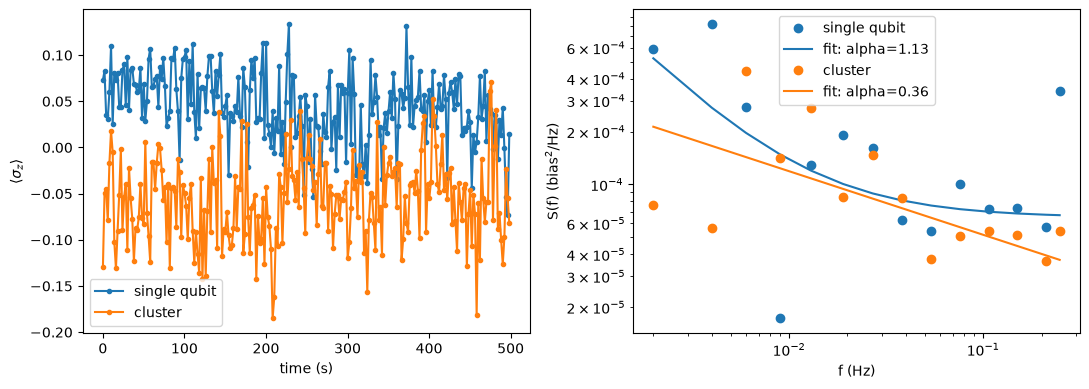

In [13]:
# analyse
def one_over_f(f, A, alpha, c):
    return A**2 / f**alpha + c

def fit_one_over_f(times, h):
    "Fit S(f) = A^2/f^alpha + c to a time series of biases. Returns (A, alpha, c), their errors, and the binned spectrum."
    f, S = periodogram(h, fs=1 / np.median(np.diff(times)), detrend="linear")
    f, S = f[1:-1], S[1:-1]   # drop f = 0, and the top frequency (it is noisier than the rest)

    # average the noisy spectrum in log-spaced frequency bins
    bin_of = np.digitize(f, np.logspace(np.log10(f[0]), np.log10(f[-1]), 15), right=True)
    bins = np.unique(bin_of)
    f_b = np.array([f[bin_of == b].mean() for b in bins])
    S_b = np.array([S[bin_of == b].mean() for b in bins])
    n_b = np.array([np.sum(bin_of == b) for b in bins])

    # the log of an average of only a few noisy points comes out low, so we undo that
    S_b = S_b / np.exp(digamma(n_b) - np.log(n_b))

    # fit log S = log(A^2/f^alpha + c), trusting bins that hold more points more.
    # We fit log(A^2) and log(c) rather than A and c, which keeps them positive. Keeping both within
    # a (very) wide range of the data stops the fit wandering off when there is no drift to see.
    log_model = lambda f, logA2, alpha, logc: np.logaddexp(logA2 - alpha * np.log(f), logc)
    lo, hi = np.log(S_b.min()) - 20, np.log(S_b.max()) + 20
    (logA2, alpha, logc), pcov = curve_fit(
        log_model, f_b, np.log(S_b), p0=[np.log(S_b[0] * f_b[0]), 1.0, np.log(S_b[-1])],
        sigma=1 / np.sqrt(n_b), bounds=([lo, 0, lo], [hi, 3, hi]), max_nfev=10_000,
    )
    logA2_err, alpha_err, logc_err = np.sqrt(np.diag(pcov))
    A, c = np.exp(logA2 / 2), np.exp(logc)
    return (A, alpha, c), (A * logA2_err / 2, alpha_err, c * logc_err), f_b, S_b

spins_q = [mean_spin(s, [TARGET_QUBIT]) for s in results]
spins_c = [mean_spin(s, cluster) for s in results]

fits = {}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for label, spins, w in (("single qubit", spins_q, w_tanh), ("cluster", spins_c, w_cluster)):
    fits[label] = fit_one_over_f(times, w * np.array(spins))
    (A, alpha, c), (A_err, alpha_err, _), f_b, S_b = fits[label]
    # we have seen the drift if the 1/f part rises above the floor at our lowest frequency, and alpha is clearly above 0
    seen = A**2 / f_b[0]**alpha > c and alpha > 2 * alpha_err
    print(f"{label}: alpha = {alpha:.2f} +-{alpha_err:.2f}, A = {A:.1e} +-{A_err:.1e} /sqrt(Hz), floor c = {c:.1e} /Hz")
    print(f"  -> {'drift seen above the floor' if seen else 'drift NOT seen above the floor, so alpha is not reliable'}")

    ax1.plot(times, spins, '.-', label=label)
    ax2.loglog(f_b, S_b, 'o', label=label)
    ax2.loglog(f_b, one_over_f(f_b, A, alpha, c), '-', color=ax2.lines[-1].get_color(), label=f'fit: alpha={alpha:.2f}')

# the single qubit's amplitude in flux units, to compare with the docs
(A, _, _), (A_err, _, _), _, _ = fits["single qubit"]
A_flux, A_flux_err = abs(h_to_fluxbias(np.array([A, A_err]), B=B_FREEZEOUT_GHZ, MAFM=MAFM_PH))
print(f"single qubit: A = {A_flux*1e6:.1f} +-{A_flux_err*1e6:.1f} uPhi_0/sqrt(Hz)  (docs: ~2)")

ax1.set(xlabel='time (s)', ylabel=r'$\langle\sigma_z\rangle$')
ax2.set(xlabel='f (Hz)', ylabel='S(f) (bias$^2$/Hz)')
ax1.legend()
ax2.legend()
fig.tight_layout()
plt.show()

## System-Level Benchmarking

Here we do three experiments:

- native-graph random spin glass
    - weights in $\{\pm5, \pm6, \pm7\}$
    - 50 instances per N
    - N from small to large
    - anneal time sweep? ignore for now
    - spin reversal gauges? ignore for now
    - randomised placement on the real chip
    - gurobi classical solver
- fair degenerate sampling
    - a ring with many degenerate ground states to ensure each is equally sampled
- chain breaking
    - how long a chain of qubits can get before it stops acting as one logical qubit

### Native-Graph Random Spin Glass

The hardest problems for an annealer are the ones it was built for: random spin glasses laid out directly on the
native graph, so there is no embedding overhead to confound the result.

Each instance is a randomly-placed connected patch of $N$ qubits with zero biases and integer couplings drawn from
$\{\pm5,\pm6,\pm7\}$. We keep the weights as integers throughout and only divide by 7 at submission time (so that
$J\in[-1,1]$ is respected with `auto_scale=False`); this means energies compare *exactly* against the classical
optimum, with no floating-point slack.

Gurobi solves each instance exactly, so we can ask two questions as $N$ grows:

- how often does the QPU actually land in the ground state?
- when it misses, how far off is its best read?

Note: this submits `NUM_INSTANCES` jobs per size. Tiling instances across the chip would compress that a lot,
but is left out here to keep the proof of concept readable.

In [14]:
# instance generation and classical reference
import gurobipy as gp
import networkx as nx

WEIGHTS = [-7, -6, -5, 5, 6, 7]   # integer coupler weights; divided by J_SCALE on submission
J_SCALE = 7

rng = np.random.default_rng(0)

def random_subgraph(G, N):
    "Grow a connected N-qubit patch from a random seed node, randomising placement on the chip."
    nodes = {int(rng.choice(G.nodes))}
    while len(nodes) < N:
        frontier = list({n for v in nodes for n in G[v]} - nodes)
        nodes.add(int(rng.choice(frontier)))
    return G.subgraph(nodes)

def gurobi_ground_energy(J):
    "Exact Ising ground-state energy for integer couplings J (all h=0), as a binary quadratic program."
    model = gp.Model()
    model.Params.OutputFlag = 0
    x = {v: model.addVar(vtype=gp.GRB.BINARY) for v in {v for edge in J for v in edge}}
    # spins are s = 2x - 1
    model.setObjective(gp.quicksum(w * (2 * x[i] - 1) * (2 * x[j] - 1) for (i, j), w in J.items()))
    model.optimize()
    return round(model.ObjVal)

In [15]:
# run: NUM_INSTANCES random instances at each size (unless this run already has them)
NUM_ANNEALS = 1000
SIZES = [8, 16, 32, 64, 128]
NUM_INSTANCES = 50

data = load("spin_glass")
if data is None:
    instances = []
    with DWaveSampler(solver=SOLVER) as sampler:
        for N in SIZES:
            for _ in range(NUM_INSTANCES):
                J = {e: int(rng.choice(WEIGHTS)) for e in random_subgraph(G, N).edges}
                E_opt = gurobi_ground_energy(J)
                res = sampler.sample_ising(
                    {}, {e: w / J_SCALE for e, w in J.items()},
                    num_reads=NUM_ANNEALS, auto_scale=False, label=f"spin glass N={N}",
                )
                instances.append(dict(N=N, J=J_to_list(J), E_opt=E_opt, samples=res))
            print(f"N = {N}: done")
    data = save("spin_glass", num_anneals=NUM_ANNEALS, J_scale=J_SCALE, instances=instances)

# (N, integer couplings J, exact ground energy, sampleset) for every instance; and the settings this run was taken with
instances = [(d["N"], J_from_list(d["J"]), d["E_opt"], d["samples"]) for d in data["instances"]]
NUM_ANNEALS, J_SCALE = data["num_anneals"], data["J_scale"]
SIZES = sorted({N for N, *_ in instances})

Restricted license - for non-production use only - expires 2027-11-29
N = 8: done
N = 16: done
N = 32: done
N = 64: done
N = 128: done
saved data\2026-09-22\spin_glass.json.gz


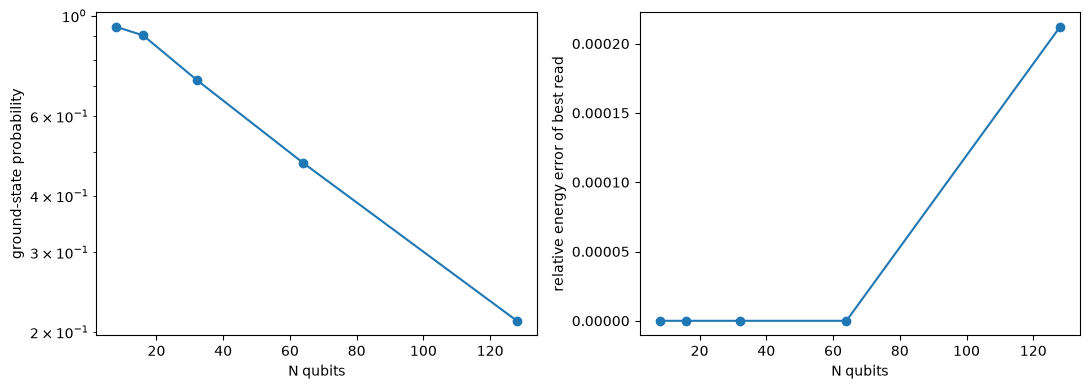

In [16]:
# analyse: how often does the QPU find the true ground state, and how close does it get when it misses?
success, gap = {}, {}
for N, J, E_opt, res in instances:
    energies = np.round(res.record.energy * J_SCALE)   # back into integer units
    hits = res.record.num_occurrences[energies == E_opt].sum()
    success.setdefault(N, []).append(hits / NUM_ANNEALS)
    gap.setdefault(N, []).append((energies.min() - E_opt) / abs(E_opt))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.semilogy(SIZES, [np.mean(success[N]) for N in SIZES], 'o-')
ax1.set(xlabel='N qubits', ylabel='ground-state probability')
ax2.plot(SIZES, [np.mean(gap[N]) for N in SIZES], 'o-')
ax2.set(xlabel='N qubits', ylabel='relative energy error of best read')
fig.tight_layout()
plt.show()

### Fair Degenerate Sampling

Finding *a* ground state is not the whole story: when a problem has many ground states, a good sampler should
return all of them equally often. Annealers are known to be biased here, favouring ground states with a wide
basin around them.

The cleanest probe is a frustrated ring. Take a native cycle of $L$ qubits, make every coupler ferromagnetic
except one. The odd antiferromagnetic bond means the ring cannot satisfy every coupler at once: exactly one bond
must be broken, and it can be *any* of the $L$ bonds. With the global spin flip that gives $2L$ ground states,
all at energy $2-L$, all exactly degenerate.

We use a cycle that exists natively in the hardware graph rather than an embedded one, since chain breaks would
contaminate a fairness measurement. Then we histogram the ground states and measure the total-variation distance
from uniform: 0 is perfectly fair, 1 is maximally biased.

In [17]:
# a frustrated ring: one broken bond, anywhere in the ring -> 2L degenerate ground states
L = 16
NUM_ANNEALS = 2000

# run (unless this run already has it)
data = load("fair_sampling")
if data is None:
    ring = next(c for c in nx.simple_cycles(G, length_bound=L) if len(c) == L)
    bonds = list(zip(ring, ring[1:] + ring[:1]))
    J_ring = {bond: -1.0 for bond in bonds}
    J_ring[bonds[0]] = +1.0   # the one antiferromagnetic coupler frustrates the ring

    with DWaveSampler(solver=SOLVER) as sampler:
        ring_samples = sampler.sample_ising({}, J_ring, num_reads=NUM_ANNEALS, auto_scale=False, label="frustrated ring")
    data = save("fair_sampling", ring=ring, J=J_to_list(J_ring), samples=ring_samples)

# the ring's couplers are in order around the ring; and the settings this run was taken with
ring, J_ring, ring_samples = data["ring"], J_from_list(data["J"]), data["samples"]
L, NUM_ANNEALS = len(ring), ring_samples.record.num_occurrences.sum()

saved data\2026-09-22\fair_sampling.json.gz


reads in a ground state: 100.0%
total-variation distance from uniform: 0.152


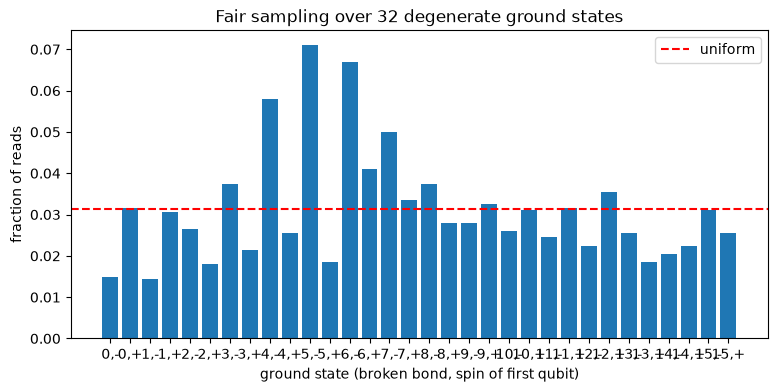

In [18]:
# label each ground state by (which bond is broken, spin of the first qubit), then compare to uniform
from collections import Counter

counts = Counter()
for s, n in zip(ring_samples.samples(), ring_samples.record.num_occurrences):
    broken = [i for i, ((u, v), w) in enumerate(J_ring.items()) if w * s[u] * s[v] > 0]
    if len(broken) == 1:   # exactly one broken bond == ground state
        counts[(broken[0], s[ring[0]])] += n

states = [(i, spin) for i in range(L) for spin in (-1, 1)]
freqs = np.array([counts[state] for state in states]) / NUM_ANNEALS
tvd = 0.5 * np.abs(freqs / freqs.sum() - 1 / len(states)).sum()

print(f"reads in a ground state: {100 * freqs.sum():.1f}%")
print(f"total-variation distance from uniform: {tvd:.3f}")

plt.figure(figsize=(9, 4))
plt.bar(range(len(states)), freqs)
plt.axhline(freqs.sum() / len(states), color='r', ls='--', label='uniform')
plt.xticks(range(len(states)), [f"{i},{'+' if spin > 0 else '-'}" for i, spin in states])
plt.xlabel('ground state (broken bond, spin of first qubit)')
plt.ylabel('fraction of reads')
plt.legend()
plt.title(f"Fair sampling over {2 * L} degenerate ground states")
plt.show()

### Chain Breaking

Any problem too dense for the native graph has to be embedded, which means one logical qubit becomes a
*chain* of physical qubits held together by strong ferromagnetic couplers. The chain is only useful while it
stays aligned: once it breaks, the logical value is ambiguous and has to be guessed by majority vote. So the
question worth asking is how long a chain can get before it stops holding.

We carve disjoint length-$L$ paths straight out of the working graph and run them all in a single job. As with the
temperature sweep, the parallelism comes for free: hundreds of independent chains fit on the chip at once, so one job
gives `chains` $\times$ `num_reads` chain samples. The carving leaves a one-qubit gap around every chain, so no
coupler exists between two chains and they cannot influence each other.

Each length is run in two conditions:

- **idle**: $h=0$, so a break can only come from thermal noise and control error
- **stressed**: $h=\pm$`STRESS` on the two end qubits, putting the chain in a tug-of-war it has to resolve

`STRESS` must be smaller than $|J_\text{chain}|$. If the two are equal the broken state is exactly degenerate
with the intact one and roughly a third of chains break even at $L=2$ -- that measures degeneracy, not chain
robustness. Kept below it, a domain wall costs energy while the number of places to put one grows with $L$, so
the break rate climbs with length for a real physical reason.

We record two things: how often chains break, and how badly (the fraction of qubits sitting in the minority,
which is what decides whether a majority vote still recovers the right logical value).

In [19]:
# carve disjoint chains, spaced out so they cannot influence each other
def native_chains(G, L, max_chains=200):
    "Carve disjoint length-L paths by random walks, leaving a gap so no two chains are coupled."
    free = set(G.nodes)
    chains = []
    for start in rng.permutation(list(G.nodes)):
        if len(chains) == max_chains:
            break
        if start not in free:
            continue
        chain = [int(start)]
        while len(chain) < L:
            options = [n for n in G[chain[-1]] if n in free and n not in chain]
            if not options:
                break
            chain.append(int(rng.choice(options)))
        if len(chain) == L:
            free -= set(chain) | {n for v in chain for n in G[v]}   # drop the chain and its neighbours
            chains.append(chain)
    return chains

In [20]:
# run: every length, idle and stressed, one job each (unless this run already has them)
NUM_ANNEALS = 1000
LENGTHS = [2, 4, 8, 16, 32, 64]
CHAINS_PER_JOB = 200
J_CHAIN = -1.0
STRESS = 0.5   # must be < abs(J_CHAIN), else breaking is degenerate with staying intact

data = load("chain_breaking")
if data is None:
    runs = []
    with DWaveSampler(solver=SOLVER) as sampler:
        for L in LENGTHS:
            chains = native_chains(G, L, CHAINS_PER_JOB)
            J = {(c[i], c[i + 1]): J_CHAIN for c in chains for i in range(L - 1)}
            for stressed in (False, True):
                # tug-of-war: opposite biases on the two ends of every chain
                h = {q: bias for c in chains for q, bias in ((c[0], +STRESS), (c[-1], -STRESS))} if stressed else {}
                res = sampler.sample_ising(h, J, num_reads=NUM_ANNEALS, auto_scale=False,
                                           label=f"chains L={L} stressed={stressed}")
                runs.append(dict(L=L, stressed=stressed, chains=chains, samples=res))
            print(f"L = {L}: {len(chains)} chains per job")
    data = save("chain_breaking", J_chain=J_CHAIN, stress=STRESS, runs=runs)

# (L, stressed) -> (chains, sampleset); and the settings this run was taken with
chain_results = {(r["L"], r["stressed"]): (r["chains"], r["samples"]) for r in data["runs"]}
LENGTHS, J_CHAIN, STRESS = sorted({r["L"] for r in data["runs"]}), data["J_chain"], data["stress"]

L = 2: 200 chains per job
L = 4: 150 chains per job
L = 8: 83 chains per job
L = 16: 50 chains per job
L = 32: 29 chains per job
L = 64: 16 chains per job
saved data\2026-09-22\chain_breaking.json.gz


stressed chains start breaking (>1%) at L = 16


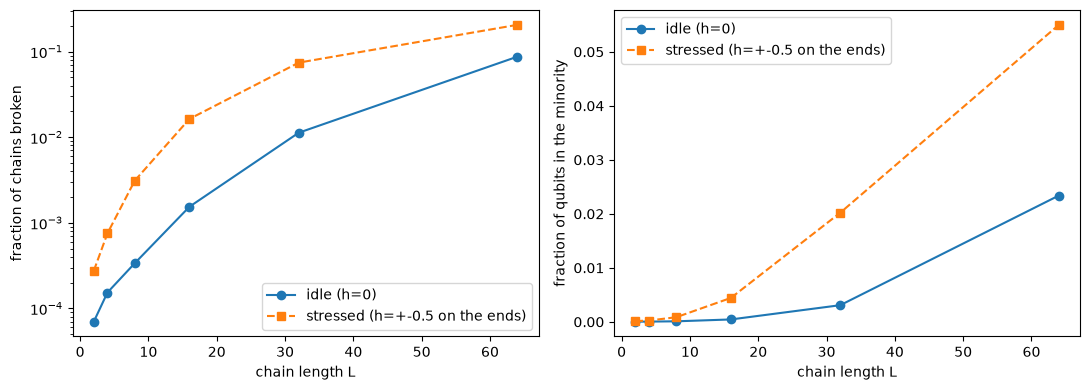

In [21]:
# analyse: how often chains break, and how badly
break_rate, severity = {}, {}
for (L, stressed), (chains, res) in chain_results.items():
    idx = {v: i for i, v in enumerate(res.variables)}
    spins = np.stack([res.record.sample[:, [idx[q] for q in c]] for c in chains])   # (chains, reads, L)
    broken = (spins != spins[..., :1]).any(axis=2)                                  # any qubit out of line
    minority = np.minimum((spins == 1).sum(axis=2), (spins == -1).sum(axis=2)) / L  # how badly
    weights = np.broadcast_to(res.record.num_occurrences, broken.shape)
    break_rate[(L, stressed)] = np.average(broken, weights=weights)
    severity[(L, stressed)] = np.average(minority, weights=weights)

onset = [L for L in LENGTHS if break_rate[(L, True)] > 0.01]
print(f"stressed chains start breaking (>1%) at L = {onset[0] if onset else 'never in this range'}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for stressed, style in ((False, 'o-'), (True, 's--')):
    label = f'stressed (h=+-{STRESS} on the ends)' if stressed else 'idle (h=0)'
    ax1.semilogy(LENGTHS, [max(break_rate[(L, stressed)], 1e-5) for L in LENGTHS], style, label=label)
    ax2.plot(LENGTHS, [severity[(L, stressed)] for L in LENGTHS], style, label=label)
ax1.set(xlabel='chain length L', ylabel='fraction of chains broken')
ax2.set(xlabel='chain length L', ylabel='fraction of qubits in the minority')
ax1.legend()
ax2.legend()
fig.tight_layout()
plt.show()